# 📦 1. Toolkit Preparation


## Installing Libraries


In [ ]:
# %pip install scikit-learn seaborn tensorflow


## Importing Libraries


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Bidirectional,
    Dense,
    Dropout,
    Embedding,
    GlobalMaxPooling1D,
    Input,
    LSTM,
)
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.regularizers import l2

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# 📤 2. Data Loading


In [49]:
df = pd.read_csv("data/app_reviews_ready.csv")
print("Total rows:", len(df))
df.head()


Total rows: 15963


,score,clean_content,minimal_content,roberta_sentiment
0,1,I have a continuous problem! Do not recognize ...,i have a continuous problem! do not recognize ...,negative
1,3,Read new to eat,read new to eat,neutral
2,5,Learn very good pronunciation. Identify errors...,learn very good pronunciation. identify error ...,positive
3,1,I did not like the application because there i...,i do not like the application because there be...,negative
4,5,Make it easier to study English,make it easy to study english,neutral


# 🏗️ 3. Experiment Preparation

## Data Labeling

In [50]:
def label_review(sentiment):
    if sentiment == "negative":
        return 0
    elif sentiment == "neutral":
        return 1
    else:
        return 2


def binary_label_review(sentiment):
    if sentiment == "negative":
        return 0
    else:
        return 1


df["sentiment"] = df["roberta_sentiment"].apply(label_review)
df["sentiment_bi"] = df["roberta_sentiment"].apply(binary_label_review)

df.head()


,score,clean_content,minimal_content,roberta_sentiment,sentiment,sentiment_bi
0,1,I have a continuous problem! Do not recognize ...,i have a continuous problem! do not recognize ...,negative,0,0
1,3,Read new to eat,read new to eat,neutral,1,1
2,5,Learn very good pronunciation. Identify errors...,learn very good pronunciation. identify error ...,positive,2,1
3,1,I did not like the application because there i...,i do not like the application because there be...,negative,0,0
4,5,Make it easier to study English,make it easy to study english,neutral,1,1


## Data Splitting

In [ ]:
# Check distributions to confirm stratification worked.
def check_distributions(train, val, test):
    print("Train distribution:\n", train.value_counts())
    print("\nValidation distribution:\n", val.value_counts())
    print("\nTest distribution:\n", test.value_counts())


def stratified_train_val_test_split(
    df,
    y_column,
    test_size=0.3,
    val_size=0.5,
    random_state=42,
    stratify=True,
    distribution_check=True,
):
    stratify_labels = df[y_column] if stratify else None

    # First split: Train (70%) + Temp (validation + test) (30%).
    train_df, temp_df = train_test_split(
        df, test_size=test_size, stratify=stratify_labels, random_state=random_state
    )

    # Second split: Validation (15%) + Test (15%).
    stratify_temp = temp_df[y_column] if stratify else None
    val_df, test_df = train_test_split(
        temp_df,
        test_size=val_size,
        stratify=stratify_temp,
        random_state=random_state,
    )

    # Verify split.
    if distribution_check:
        check_distributions(train_df[y_column], val_df[y_column], test_df[y_column])

    return train_df, val_df, test_df


In [52]:
train_df, val_df, test_df = stratified_train_val_test_split(df, y_column="sentiment")

# Save splits.
train_df.to_csv("history/train.csv", index=False)
val_df.to_csv("history/val.csv", index=False)
test_df.to_csv("history/test.csv", index=False)


Train distribution:
 sentiment
1    3725
0    3725
2    3724
Name: count, dtype: int64

Validation distribution:
 sentiment
0    798
1    798
2    798
Name: count, dtype: int64

Test distribution:
 sentiment
2    799
1    798
0    798
Name: count, dtype: int64


In [53]:
train_df_bi, val_df_bi, test_df_bi = stratified_train_val_test_split(
    df, y_column="sentiment_bi"
)

# Save splits.
train_df_bi.to_csv("history/train_bi.csv", index=False)
val_df_bi.to_csv("history/val_bi.csv", index=False)
test_df_bi.to_csv("history/test_bi.csv", index=False)


Train distribution:
 sentiment_bi
1    7449
0    3725
Name: count, dtype: int64

Validation distribution:
 sentiment_bi
1    1596
0     798
Name: count, dtype: int64

Test distribution:
 sentiment_bi
1    1597
0     798
Name: count, dtype: int64


## Training

In [ ]:
# Calculate class weights for handling class imbalance.
def get_class_weights(y_train):
    class_weights = class_weight.compute_class_weight(
        class_weight="balanced", classes=np.unique(y_train), y=y_train
    )
    return dict(enumerate(class_weights))


# Train.
def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs,
    callbacks,
    class_weight=None,
):
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )

    return history


## Evaluation

In [ ]:
def plot_history(history, experiment_code):
    plt.plot(history["accuracy"], label="train acc")
    plt.plot(history["val_accuracy"], label="val acc")
    plt.title(f"Model Accuracy — Experiment {experiment_code}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(f"history/train_history_acc_{experiment_code}.png")
    plt.show()

    plt.plot(history["loss"], label="train loss")
    plt.plot(history["val_loss"], label="val loss")
    plt.title(f"Model Loss — Experiment {experiment_code}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(f"history/train_history_loss_{experiment_code}.png")
    plt.show()


def evaluate_model(model, X_test, y_test, class_names, labels, experiment_code):
    # Predictions on test set.
    y_pred = model.predict(X_test).argmax(axis=1)

    # Accuracy.
    print("Test Accuracy:", accuracy_score(y_test, y_pred))

    # Detailed report.
    print(
        "\nClassification Report:\n",
        classification_report(y_test, y_pred, digits=4, target_names=class_names),
    )

    # Confusion matrix.
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — Experiment {experiment_code}")
    plt.tight_layout()
    plt.savefig(f"history/confusion_matrix_{experiment_code}.png")
    plt.show()


# 1️⃣ Experiment A

## Feature Extraction

In [187]:
# Load splits.
train_df = pd.read_csv("history/train.csv")
val_df = pd.read_csv("history/val.csv")
test_df = pd.read_csv("history/test.csv")

# Convert text to TF-IDF features.
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

# Fit on training data only to prevent information leakage.
X_train = vectorizer.fit_transform(train_df["minimal_content"])

# Transform validation and test data.
X_val = vectorizer.transform(val_df["minimal_content"])
X_test = vectorizer.transform(test_df["minimal_content"])

# Extract labels.
y_train = train_df["sentiment"].values
y_val = val_df["sentiment"].values
y_test = test_df["sentiment"].values

# Save the processing tool (TF-IDF vectorizer).
joblib.dump(vectorizer, "history/vectorizer_A.pkl")

# Shapes.
print(
    f"Shapes:\nTrain: {X_train.shape}\nValidation: {X_val.shape}\nTest: {X_test.shape}"
)


Shapes:
Train: (11174, 10000)
Validation: (2394, 10000)
Test: (2395, 10000)


## Model Setup

In [188]:
# Define model.
model = Sequential(
    [
        Input(shape=(X_train.shape[1],)),
        Dense(128, activation="relu", kernel_regularizer=l2(1e-3)),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=l2(1e-3)),
        Dropout(0.5),
        Dense(3, activation="softmax"),
    ]
)

# Compile model.
model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Summary.
model.summary()


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_83 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,355 (4.90 MB)

 Trainable params: 1,284,355 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [189]:
# Callbacks.
# Save the full model (architecture, weights, traning config).
checkpoint = ModelCheckpoint(
    "history/best_model_A.keras", monitor="val_loss", save_best_only=True
)

early_stop = EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, verbose=1)

# Train.
history = train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=40,
    callbacks=[checkpoint, early_stop, reduce_lr],
)

# Save training history.
pd.DataFrame(history.history).to_csv("history/history_A.csv", index=False)


Epoch 1/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5650 - loss: 1.0704 - val_accuracy: 0.7398 - val_loss: 0.8341 - learning_rate: 3.0000e-04
Epoch 2/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7430 - loss: 0.7647 - val_accuracy: 0.7749 - val_loss: 0.6743 - learning_rate: 3.0000e-04
Epoch 3/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8048 - loss: 0.6419 - val_accuracy: 0.7945 - val_loss: 0.6444 - learning_rate: 3.0000e-04
Epoch 4/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8355 - loss: 0.5974 - val_accuracy: 0.7970 - val_loss: 0.6409 - learning_rate: 3.0000e-04
Epoch 5/40
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8560 - loss: 0.5559 - val_accuracy: 0.8062 - val_loss: 0.6399 - learning_rate: 3.0000e-04
Epoch 6/40
346/350 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8803 - loss: 0.5252
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0

## Model Evaluation

### Training Curves

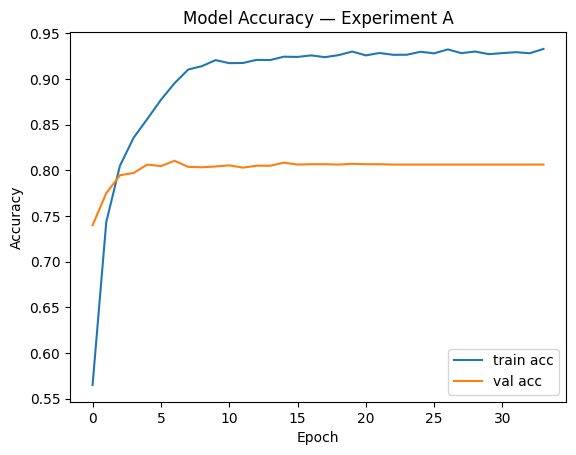

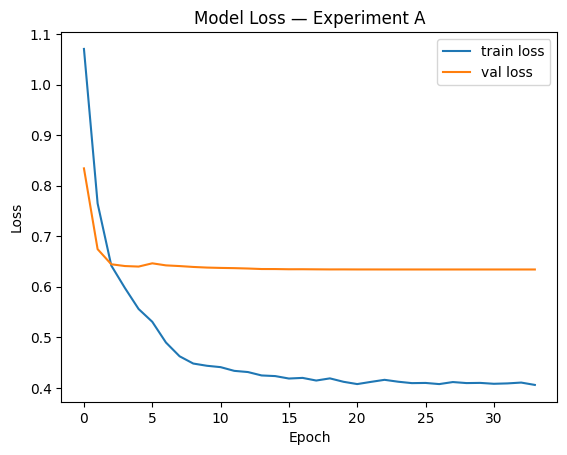

In [191]:
history = pd.read_csv("history/history_A.csv")
plot_history(history, experiment_code="A")


### Evaluation Metrics

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Test Accuracy: 0.8116910229645093

Classification Report:
               precision    recall  f1-score   support

    Negative     0.8302    0.8271    0.8286       798
     Neutral     0.7400    0.7456    0.7428       798
    Positive     0.8656    0.8623    0.8639       799

    accuracy                         0.8117      2395
   macro avg     0.8119    0.8117    0.8118      2395
weighted avg     0.8120    0.8117    0.8118      2395



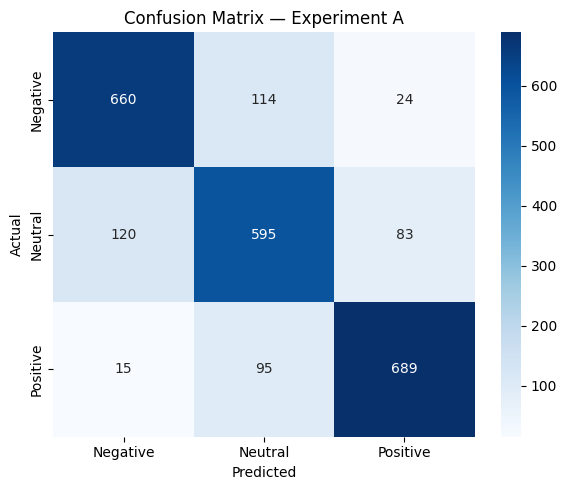

In [190]:
model = load_model("history/best_model_A.keras")

evaluate_model(
    model,
    X_test,
    y_test,
    class_names=["Negative", "Neutral", "Positive"],
    labels=[0, 1, 2],
    experiment_code="A",
)


# 2️⃣ Experiment B

## Feature Extraction

In [168]:
train_df = pd.read_csv("history/train.csv")
val_df = pd.read_csv("history/val.csv")
test_df = pd.read_csv("history/test.csv")

# Tokenization (build vocab index).
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["minimal_content"])

train_sequences = tokenizer.texts_to_sequences(train_df["minimal_content"])
val_sequences = tokenizer.texts_to_sequences(val_df["minimal_content"])
test_sequences = tokenizer.texts_to_sequences(test_df["minimal_content"])

# Padding (equal length sequences).
lengths = train_df["minimal_content"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else 0
)  # Compute review lengths.
max_length = int(np.percentile(lengths, 95))
print(f"Max sequence length set to: {max_length}\n")

X_train = pad_sequences(train_sequences, maxlen=max_length, padding="post")
X_val = pad_sequences(val_sequences, maxlen=max_length, padding="post")
X_test = pad_sequences(test_sequences, maxlen=max_length, padding="post")

y_train = train_df["sentiment"].values
y_val = val_df["sentiment"].values
y_test = test_df["sentiment"].values

# Save tokenizer.
token_json = tokenizer.to_json()
with open("history/tokenizer_B.json", "w") as file:
    file.write(token_json)

print(
    f"Shapes:\nTrain: {X_train.shape}\nValidation: {X_val.shape}\nTest: {X_test.shape}"
)


Max sequence length set to: 50

Shapes:
Train: (11174, 50)
Validation: (2394, 50)
Test: (2395, 50)


## Model Setup

In [169]:
model = Sequential(
    [
        Embedding(input_dim=10000, output_dim=100),
        Bidirectional(
            LSTM(
                128,
                return_sequences=True,
                dropout=0.3,
                recurrent_dropout=0.3,
                kernel_regularizer=l2(1e-4),
            )
        ),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
        Dropout(0.4),
        Dense(3, activation="softmax"),
    ]
)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [170]:
checkpoint = ModelCheckpoint(
    "history/best_model_B.keras", monitor="val_loss", save_best_only=True
)

early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1
)

history = train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=25,
    callbacks=[checkpoint, early_stop, lr_scheduler],
)

pd.DataFrame(history.history).to_csv("history/history_B.csv", index=False)


Epoch 1/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 143ms/step - accuracy: 0.5562 - loss: 0.9502 - val_accuracy: 0.7164 - val_loss: 0.7451 - learning_rate: 3.0000e-04
Epoch 2/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 76s 125ms/step - accuracy: 0.7500 - loss: 0.6299 - val_accuracy: 0.7711 - val_loss: 0.5703 - learning_rate: 3.0000e-04
Epoch 3/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 50s 144ms/step - accuracy: 0.8065 - loss: 0.5051 - val_accuracy: 0.7916 - val_loss: 0.5320 - learning_rate: 3.0000e-04
Epoch 4/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - accuracy: 0.8347 - loss: 0.4405 - val_accuracy: 0.8008 - val_loss: 0.5131 - learning_rate: 3.0000e-04
Epoch 5/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 77s 109ms/step - accuracy: 0.8588 - loss: 0.3878 - val_accuracy: 0.7937 - val_loss: 0.5286 - learning_rate: 3.0000e-04
Epoch 6/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 44s 117ms/step - accuracy: 0.8736 - loss: 0.3586 - val_accuracy: 0.8033 - val_loss: 0.5148 - learning_rate: 3.0000e-04
Epoch 7/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 113

## Model Evaluation

### Training Curves

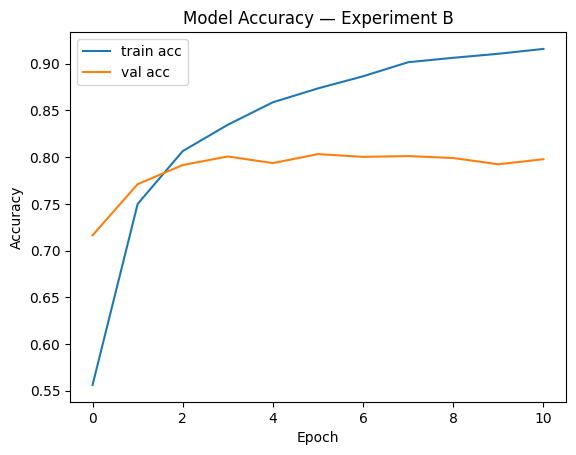

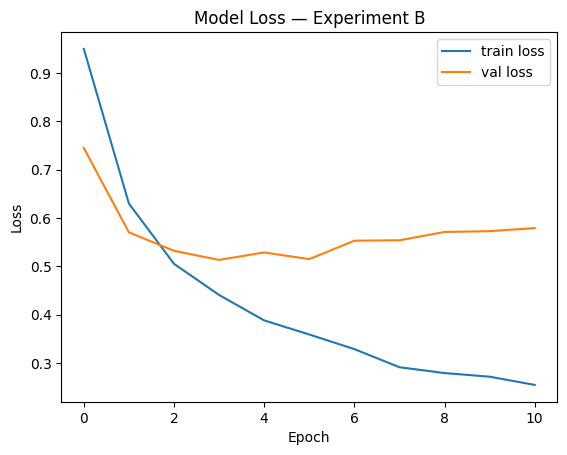

In [192]:
history = pd.read_csv("history/history_B.csv")
plot_history(history, experiment_code="B")


### Evaluation Metrics

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Test Accuracy: 0.8025052192066806

Classification Report:
               precision    recall  f1-score   support

    Negative     0.8169    0.8221    0.8195       798
     Neutral     0.7164    0.7343    0.7252       798
    Positive     0.8786    0.8511    0.8646       799

    accuracy                         0.8025      2395
   macro avg     0.8040    0.8025    0.8031      2395
weighted avg     0.8040    0.8025    0.8031      2395



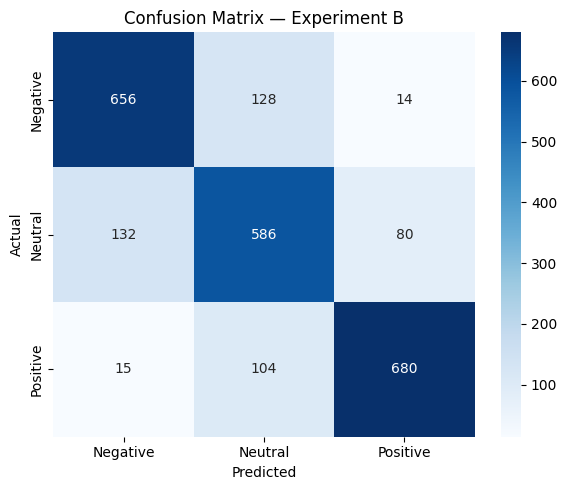

In [171]:
model = load_model("history/best_model_B.keras")

evaluate_model(
    model,
    X_test,
    y_test,
    class_names=["Negative", "Neutral", "Positive"],
    labels=[0, 1, 2],
    experiment_code="B",
)


# 3️⃣ Experiment C

## Feature Extraction

In [62]:
train_df = pd.read_csv("history/train_bi.csv")
val_df = pd.read_csv("history/val_bi.csv")
test_df = pd.read_csv("history/test_bi.csv")

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(train_df["minimal_content"])

X_val = vectorizer.transform(val_df["minimal_content"])
X_test = vectorizer.transform(test_df["minimal_content"])

y_train = train_df["sentiment_bi"].values
y_val = val_df["sentiment_bi"].values
y_test = test_df["sentiment_bi"].values

joblib.dump(vectorizer, "history/vectorizer_C.pkl")

print(
    f"Shapes:\nTrain: {X_train.shape}\nValidation: {X_val.shape}\nTest: {X_test.shape}"
)


Shapes:
Train: (11174, 10000)
Validation: (2394, 10000)
Test: (2395, 10000)


## Model Setup

In [63]:
model = Sequential(
    [
        Input(shape=(X_train.shape[1],)),
        Dense(128, activation="relu", kernel_regularizer=l2(1e-3)),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=l2(1e-3)),
        Dropout(0.5),
        Dense(2, activation="softmax"),
    ]
)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,322 (4.90 MB)

 Trainable params: 1,284,322 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [64]:
class_weights = get_class_weights(y_train)
print(f"Class weights: {class_weights}\n")

checkpoint = ModelCheckpoint(
    "history/best_model_C.keras", monitor="val_loss", save_best_only=True
)

early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

history = train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=50,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights,
)

pd.DataFrame(history.history).to_csv("history/history_C.csv", index=False)


Class weights: {0: np.float64(1.4998657718120805), 1: np.float64(0.7500335615518862)}

Epoch 1/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7382 - loss: 0.6507 - val_accuracy: 0.8446 - val_loss: 0.4506
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8616 - loss: 0.4319 - val_accuracy: 0.8592 - val_loss: 0.4156
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8957 - loss: 0.3705 - val_accuracy: 0.8705 - val_loss: 0.4062
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9188 - loss: 0.3318 - val_accuracy: 0.8718 - val_loss: 0.4190
Epoch 5/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9296 - loss: 0.3100 - val_accuracy: 0.8705 - val_loss: 0.4194
Epoch 6/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9417 - loss: 0.2920 - val_accuracy: 0.8734 - val_loss: 0.4246
Epoch 7/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9476 - loss: 0.2771 - val_accuracy: 0.8684 - val_loss: 0.4456
Epoch 8/50

## Model Evaluation

### Training Curves

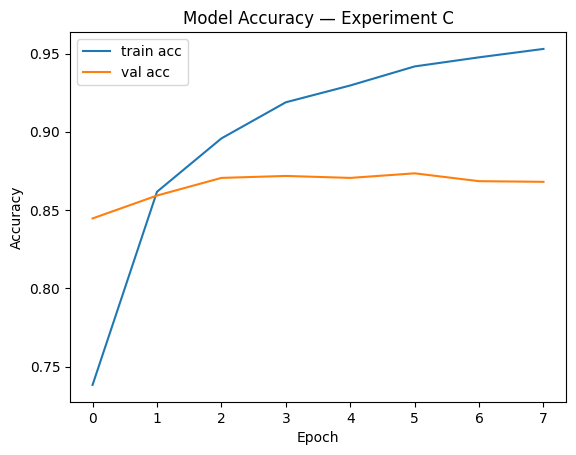

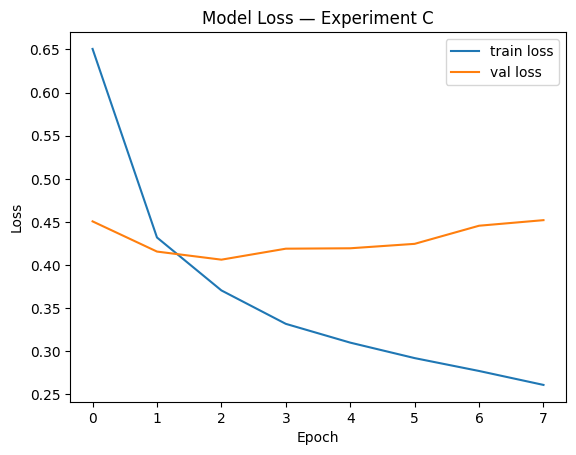

In [193]:
history = pd.read_csv("history/history_C.csv")
plot_history(history, experiment_code="C")


### Evaluation Metrics

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test Accuracy: 0.8713987473903967

Classification Report:
               precision    recall  f1-score   support

    Negative     0.7692    0.8772    0.8197       798
    Positive     0.9340    0.8685    0.9001      1597

    accuracy                         0.8714      2395
   macro avg     0.8516    0.8728    0.8599      2395
weighted avg     0.8791    0.8714    0.8733      2395



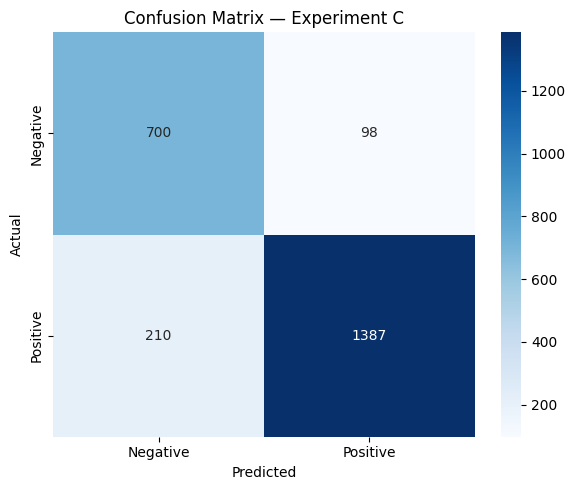

In [66]:
model = load_model("history/best_model_C.keras")

evaluate_model(
    model,
    X_test,
    y_test,
    class_names=["Negative", "Positive"],
    labels=[0, 1],
    experiment_code="C",
)
